In [1]:
# ============================================
# PROJECT 1: NAIROBI ROAD NETWORK ANALYSIS
# Tools: OSMnx, GeoPandas, Folium, Matplotlib
# ============================================

import osmnx as ox
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


✅ All libraries imported successfully!


In [2]:
# ============================================
# CELL 2: DOWNLOAD NAIROBI ROAD NETWORK
# ============================================
# OSMnx connects to OpenStreetMap and downloads
# all road data for any city in the world — for free!

print("⏳ Downloading Nairobi road network from OpenStreetMap...")
print("This may take 1-2 minutes depending on your internet...")

# Download all drivable roads in Nairobi
G = ox.graph_from_place("Nairobi, Kenya", network_type="drive")

# Convert to GeoDataFrames (spatial tables) for analysis
nodes, edges = ox.graph_to_gdfs(G)

print(f"✅ Download complete!")
print(f"📍 Total intersections (nodes): {len(nodes):,}")
print(f"🛣️  Total road segments (edges): {len(edges):,}")
print(f"🗺️  Coordinate system: {edges.crs}")

⏳ Downloading Nairobi road network from OpenStreetMap...
This may take 1-2 minutes depending on your internet...
✅ Download complete!
📍 Total intersections (nodes): 36,558
🛣️  Total road segments (edges): 89,057
🗺️  Coordinate system: epsg:4326


In [5]:
# ============================================
# CELL 3: NETWORK STATISTICS & ANALYSIS (FIXED)
# ============================================

stats = ox.basic_stats(G)

print("=" * 50)
print("   NAIROBI ROAD NETWORK ANALYSIS RESULTS")
print("=" * 50)
print(f"📏 Total road length:     {stats['edge_length_total']/1000:,.1f} km")
print(f"📊 Average road length:   {stats['edge_length_avg']:.1f} metres")
print(f"🔀 Total intersections:   {stats['intersection_count']:,}")
print(f"📍 Total nodes:           {len(nodes):,}")
print(f"🛣️  Total road segments:   {len(edges):,}")
print(f"⚡ Average node degree:   {stats['k_avg']:.2f} roads per intersection")
print("=" * 50)

# Road type breakdown
road_types = edges['highway'].explode().value_counts()
print("\n🛣️  ROAD TYPES IN NAIROBI:")
print("-" * 35)
for road_type, count in road_types.head(8).items():
    print(f"  {road_type:<25} {count:>6,} segments")

   NAIROBI ROAD NETWORK ANALYSIS RESULTS
📏 Total road length:     9,494.8 km
📊 Average road length:   106.6 metres
🔀 Total intersections:   27,263
📍 Total nodes:           36,558
🛣️  Total road segments:   89,057
⚡ Average node degree:   4.87 roads per intersection

🛣️  ROAD TYPES IN NAIROBI:
-----------------------------------
  residential               74,499 segments
  unclassified               4,963 segments
  secondary                  4,149 segments
  tertiary                   3,402 segments
  trunk                        763 segments
  primary                      524 segments
  living_street                259 segments
  secondary_link               190 segments


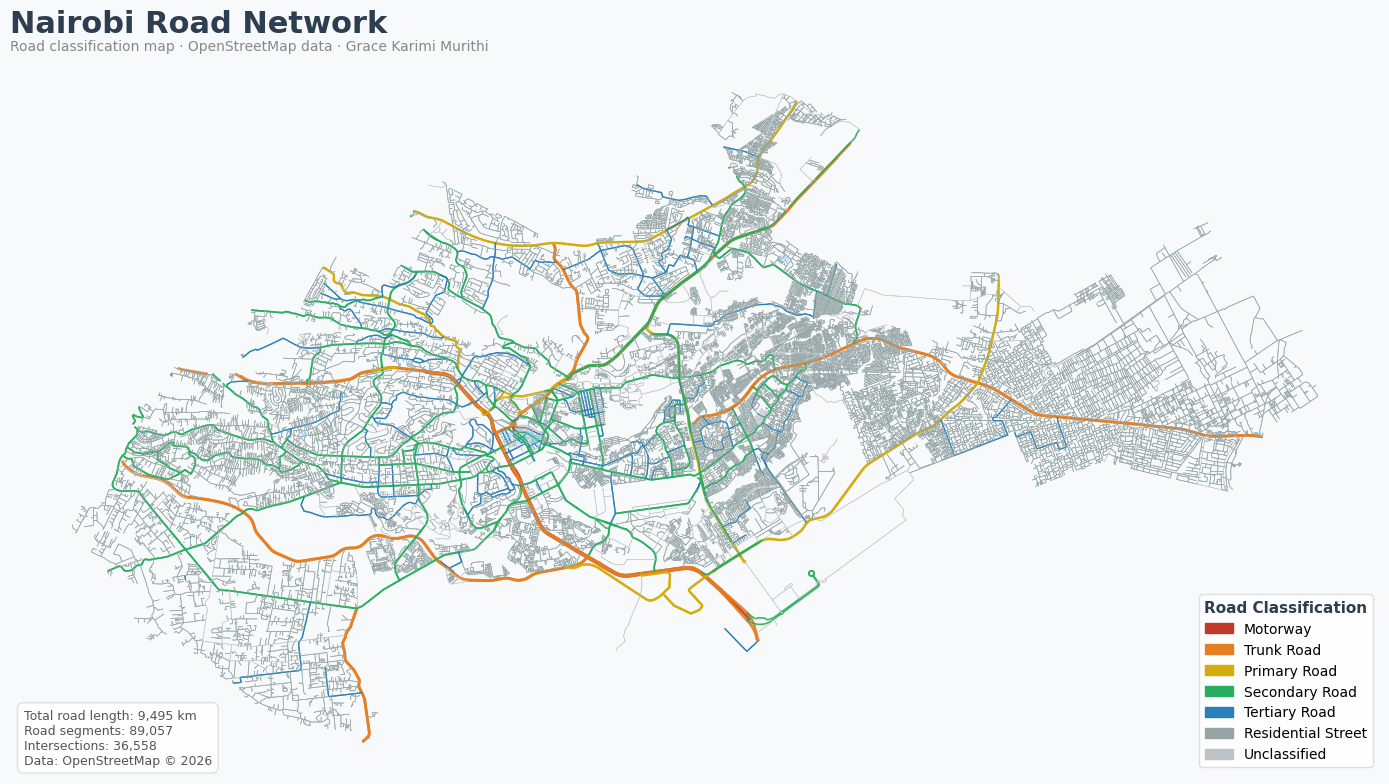

✅ Clean static map saved!


In [10]:
# ============================================
# CELL 4: CLEAN PROFESSIONAL STATIC MAP
# ============================================

import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(14, 14),
                        facecolor='#f8f9fa')
ax.set_facecolor('#f0f4f8')

# Road styling — bold colours, varied thickness
road_styles = {
    'motorway':     ('#c0392b', 2.5),
    'trunk':        ('#e67e22', 2.0),
    'primary':      ('#d4ac0d', 1.6),
    'secondary':    ('#27ae60', 1.2),
    'tertiary':     ('#2980b9', 0.9),
    'residential':  ('#95a5a6', 0.5),
    'unclassified': ('#bdc3c7', 0.4),
    'living_street':('#85c1e9', 0.4),
}

# Plot roads by type — most important on top
for road_type, (color, lw) in road_styles.items():
    mask = edges['highway'].apply(
        lambda x: road_type in x if isinstance(x, list) else x == road_type
    )
    if mask.sum() > 0:
        edges[mask].plot(ax=ax, color=color,
                        linewidth=lw, alpha=0.9)

# Clean title
ax.set_title('Nairobi Road Network',
             color='#2c3e50', fontsize=22,
             fontweight='bold', pad=20, loc='left')
ax.text(0.0, 1.01,
        'Road classification map · OpenStreetMap data · Grace Karimi Murithi',
        transform=ax.transAxes,
        fontsize=10, color='#888', va='bottom')

ax.axis('off')

# Clean white legend
legend_patches = [
    mpatches.Patch(color='#c0392b', label='Motorway'),
    mpatches.Patch(color='#e67e22', label='Trunk Road'),
    mpatches.Patch(color='#d4ac0d', label='Primary Road'),
    mpatches.Patch(color='#27ae60', label='Secondary Road'),
    mpatches.Patch(color='#2980b9', label='Tertiary Road'),
    mpatches.Patch(color='#95a5a6', label='Residential Street'),
    mpatches.Patch(color='#bdc3c7', label='Unclassified'),
]

legend = ax.legend(
    handles=legend_patches,
    loc='lower right',
    facecolor='white',
    edgecolor='#ddd',
    fontsize=10,
    framealpha=0.95,
    title='Road Classification',
    title_fontsize=11,
)
legend.get_title().set_color('#2c3e50')
legend.get_title().set_fontweight('bold')

# Stats box bottom left
stats_text = (
    f"Total road length: 9,495 km\n"
    f"Road segments: 89,057\n"
    f"Intersections: 36,558\n"
    f"Data: OpenStreetMap © 2026"
)
ax.text(0.01, 0.01, stats_text,
        transform=ax.transAxes,
        fontsize=9, color='#555',
        va='bottom',
        bbox=dict(boxstyle='round,pad=0.5',
                  facecolor='white',
                  edgecolor='#ddd',
                  alpha=0.9))

plt.tight_layout()
plt.savefig('nairobi_road_network.png', dpi=150,
            bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("✅ Clean static map saved!")

In [9]:
# ============================================
# CELL 5: BRIGHT PROFESSIONAL INTERACTIVE MAP
# ============================================

print("⏳ Creating interactive web map...")

nairobi_map = folium.Map(
    location=[-1.2921, 36.8219],
    zoom_start=12,
    tiles='CartoDB positron'  # Clean white basemap!
)

# Bold visible colours on light background
road_info = {
    'motorway':     ('#c0392b', 4.5, 'Motorway'),
    'trunk':        ('#e67e22', 3.5, 'Trunk Road'),
    'primary':      ('#d4ac0d', 3.0, 'Primary Road'),
    'secondary':    ('#27ae60', 2.0, 'Secondary Road'),
    'tertiary':     ('#2980b9', 1.5, 'Tertiary Road'),
    'residential':  ('#7f8c8d', 1.0, 'Residential Street'),
    'unclassified': ('#aab7b8', 0.8, 'Unclassified Road'),
    'living_street':('#85c1e9', 0.8, 'Living Street'),
}

# Add roads
edges_sample = edges.sample(n=min(6000, len(edges)), random_state=42)
edges_wgs = edges_sample.to_crs(epsg=4326)

for _, row in edges_wgs.iterrows():
    if row.geometry is None:
        continue
    highway = row.get('highway', 'unclassified')
    if isinstance(highway, list):
        highway = highway[0]
    color, weight, label = road_info.get(
        highway, ('#7f8c8d', 1.0, 'Other Road'))
    length = row.get('length', 0)
    name = row.get('name', 'Unnamed road')
    folium.GeoJson(
        row.geometry.__geo_interface__,
        style_function=lambda x, c=color, w=weight: {
            'color': c, 'weight': w, 'opacity': 0.9
        },
        tooltip=folium.Tooltip(
            f"<b style='color:#2c3e50'>{name}</b><br>"
            f"<span style='color:#555'>Type: {label}</span><br>"
            f"<span style='color:#555'>Length: {length:.0f} m</span>",
            sticky=False
        )
    ).add_to(nairobi_map)

# Landmarks with custom styled popups
landmarks = [
    (-1.2864, 36.8172, "🏙️ Nairobi CBD",
     "Central Business District<br>Highest road density in the city"),
    (-1.2192, 36.8855, "🛣️ Thika Superhighway (A2)",
     "Kenya's busiest expressway<br>8 lanes · Connects Nairobi to Thika"),
    (-1.3190, 36.8270, "🚛 Mombasa Road (A109)",
     "Key freight corridor to the coast<br>East Africa's main trade route"),
    (-1.2674, 36.8065, "🏢 Westlands",
     "Major commercial suburb<br>Dense secondary road network"),
    (-1.3000, 36.7820, "🌿 Lang'ata Road",
     "Southern connector<br>Links CBD to Karen & Lang'ata"),
]

for lat, lon, name, desc in landmarks:
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(
            f"""<div style='font-family:Arial; padding:6px;'>
                <b style='font-size:13px;color:#2c3e50'>{name}</b><br>
                <span style='font-size:11px;color:#555'>{desc}</span>
                </div>""",
            max_width=240),
        icon=folium.Icon(color='red', icon='info-sign'),
        tooltip=name
    ).add_to(nairobi_map)

# Clean white legend
legend_html = """
<div style="
    position: fixed; bottom: 40px; left: 40px; z-index: 1000;
    background: white;
    border: 1.5px solid #ddd;
    border-radius: 10px;
    padding: 16px 20px;
    font-family: Arial, sans-serif;
    color: #2c3e50;
    min-width: 230px;
    box-shadow: 0 4px 15px rgba(0,0,0,0.15);
">
  <p style="margin:0 0 10px 0; font-size:14px; font-weight:bold;
            color:#2c3e50; border-bottom:2px solid #27ae60;
            padding-bottom:8px;">
    🗺️ Nairobi Road Network
  </p>
  <p style="margin:0 0 8px 0; font-size:11px; 
            color:#888; font-style:italic;">
    Road Classification Legend
  </p>
  <table style="width:100%; font-size:12px; border-collapse:collapse;">
    <tr><td><span style="color:#c0392b; font-size:18px;">━━</span></td>
        <td>Motorway</td></tr>
    <tr><td><span style="color:#e67e22; font-size:18px;">━━</span></td>
        <td>Trunk Road</td></tr>
    <tr><td><span style="color:#d4ac0d; font-size:18px;">━━</span></td>
        <td>Primary Road</td></tr>
    <tr><td><span style="color:#27ae60; font-size:18px;">━━</span></td>
        <td>Secondary Road</td></tr>
    <tr><td><span style="color:#2980b9; font-size:18px;">━━</span></td>
        <td>Tertiary Road</td></tr>
    <tr><td><span style="color:#7f8c8d; font-size:18px;">━━</span></td>
        <td>Residential Street</td></tr>
    <tr><td><span style="color:#aab7b8; font-size:18px;">━━</span></td>
        <td>Unclassified Road</td></tr>
  </table>
  <div style="margin-top:12px; padding-top:10px; 
              border-top:1px solid #eee; font-size:10px; color:#999;">
    📊 89,057 segments · 9,495 km total<br>
    📍 36,558 intersections · 27,263 junctions<br>
    🖱️ Hover any road to see details<br>
    🔴 Click red markers for key roads<br><br>
    <b style="color:#2c3e50">Grace Karimi Murithi</b><br>
    Geomatics Engineering · DeKUT 2026<br>
    Data: OpenStreetMap © contributors
  </div>
</div>
"""
nairobi_map.get_root().html.add_child(folium.Element(legend_html))

# Clean title
title_html = """
<div style="
    position: fixed; top: 15px; left: 50%;
    transform: translateX(-50%);
    z-index: 1000;
    background: white;
    border: 1.5px solid #27ae60;
    border-radius: 8px;
    padding: 10px 28px;
    font-family: Arial, sans-serif;
    text-align: center;
    box-shadow: 0 2px 10px rgba(0,0,0,0.12);
">
  <p style="margin:0; font-size:16px; font-weight:bold; color:#2c3e50;">
    Nairobi Road Network Analysis
  </p>
  <p style="margin:3px 0 0 0; font-size:11px; color:#888;">
    Geomatics Engineering Project · Grace Karimi Murithi · DeKUT 2026
  </p>
</div>
"""
nairobi_map.get_root().html.add_child(folium.Element(title_html))

nairobi_map.save('nairobi_interactive_map.html')
print("✅ Map saved! Open nairobi_interactive_map.html in your browser")

⏳ Creating interactive web map...
✅ Map saved! Open nairobi_interactive_map.html in your browser


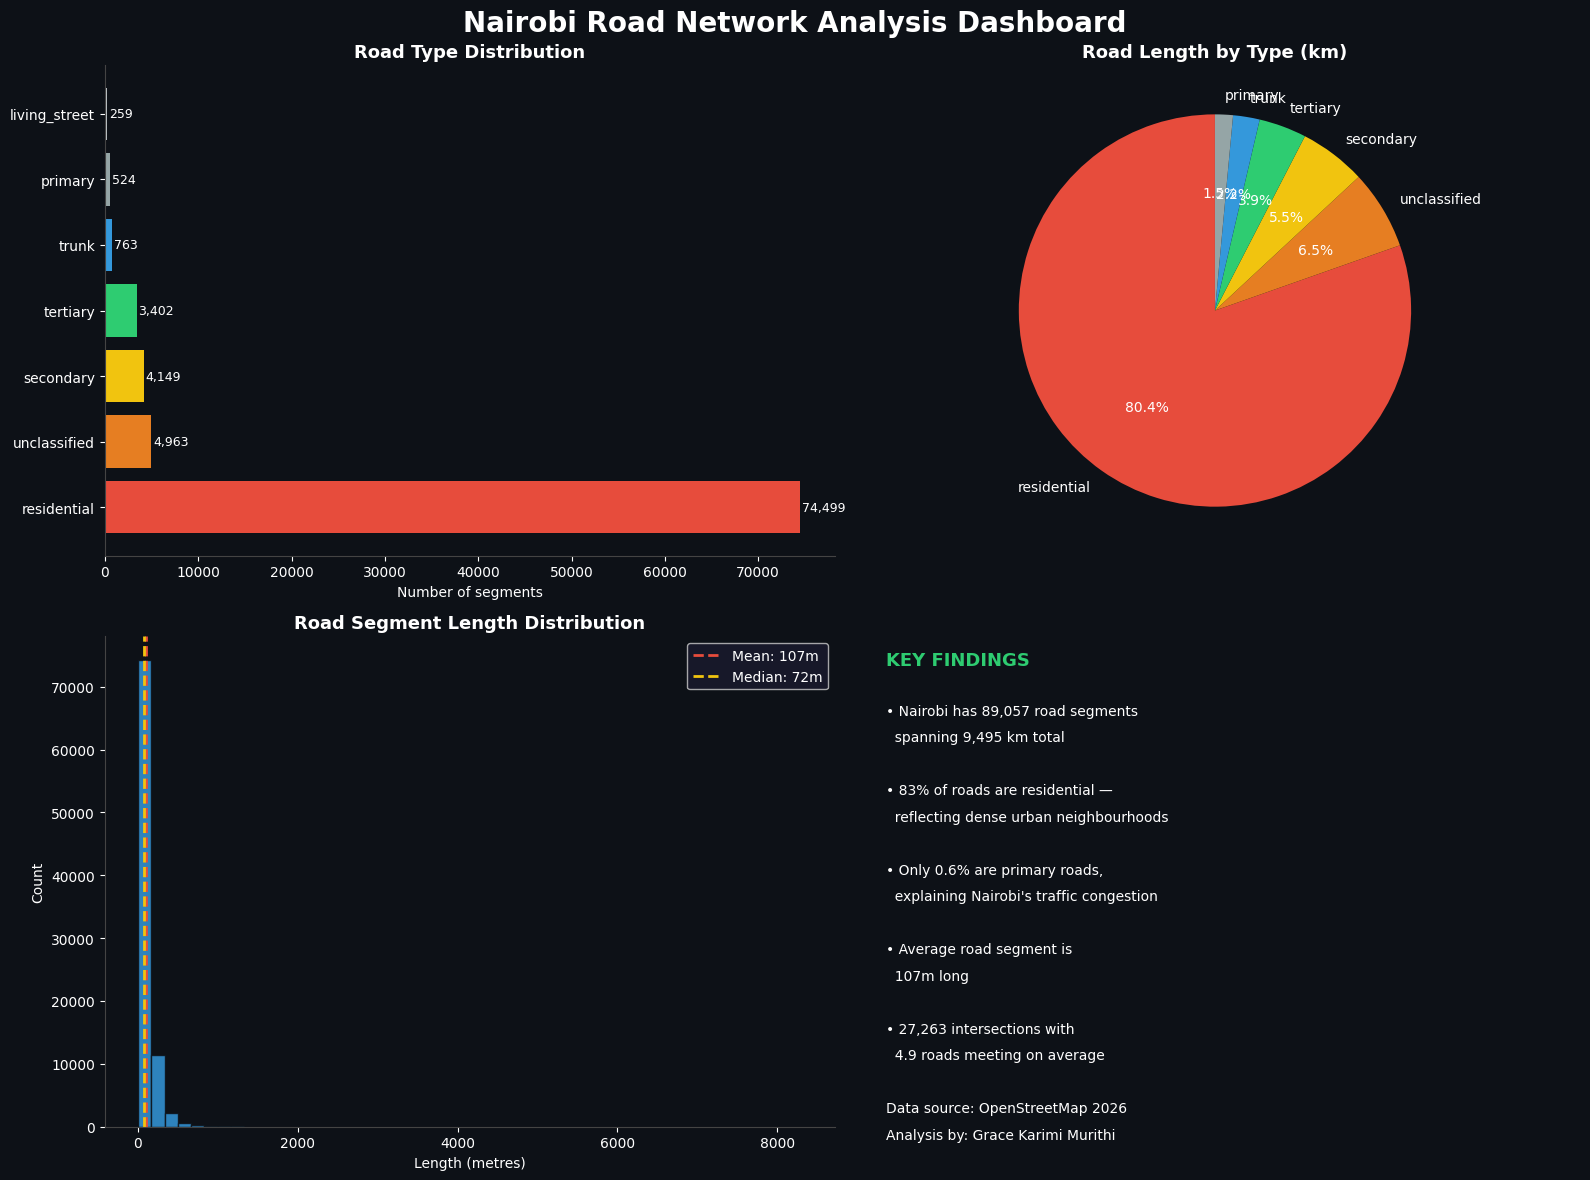

✅ Dashboard saved as nairobi_dashboard.png


In [8]:
# ============================================
# CELL 6: ANALYSIS DASHBOARD
# ============================================
# A good GIS project communicates findings!
# Let's create charts that tell Nairobi's road story

fig, axes = plt.subplots(2, 2, figsize=(16, 12),
                          facecolor='#0d1117')
fig.suptitle("Nairobi Road Network Analysis Dashboard",
             color='white', fontsize=20, fontweight='bold', y=0.98)

# --- CHART 1: Road type distribution (bar chart) ---
ax1 = axes[0, 0]
ax1.set_facecolor('#0d1117')
road_types = edges['highway'].explode().value_counts().head(7)
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71',
          '#3498db','#95a5a6','#bdc3c7']
bars = ax1.barh(road_types.index, road_types.values, color=colors)
ax1.set_title('Road Type Distribution', color='white', 
               fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of segments', color='white')
ax1.tick_params(colors='white')
ax1.spines['bottom'].set_color('#444')
ax1.spines['left'].set_color('#444')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
for bar, val in zip(bars, road_types.values):
    ax1.text(val + 200, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', color='white', fontsize=9)

# --- CHART 2: Road length by type (pie chart) ---
ax2 = axes[0, 1]
ax2.set_facecolor('#0d1117')
length_by_type = edges.groupby(
    edges['highway'].apply(lambda x: x[0] if isinstance(x, list) else x)
)['length'].sum().sort_values(ascending=False).head(6)
wedges, texts, autotexts = ax2.pie(
    length_by_type.values,
    labels=length_by_type.index,
    autopct='%1.1f%%',
    colors=colors,
    textprops={'color': 'white'},
    startangle=90
)
for autotext in autotexts:
    autotext.set_color('white')
ax2.set_title('Road Length by Type (km)', color='white',
               fontsize=13, fontweight='bold')

# --- CHART 3: Road length distribution histogram ---
ax3 = axes[1, 0]
ax3.set_facecolor('#0d1117')
ax3.hist(edges['length'], bins=50, color='#3498db',
          edgecolor='#0d1117', alpha=0.85)
ax3.axvline(edges['length'].mean(), color='#e74c3c',
             linestyle='--', linewidth=2,
             label=f"Mean: {edges['length'].mean():.0f}m")
ax3.axvline(edges['length'].median(), color='#f1c40f',
             linestyle='--', linewidth=2,
             label=f"Median: {edges['length'].median():.0f}m")
ax3.set_title('Road Segment Length Distribution',
               color='white', fontsize=13, fontweight='bold')
ax3.set_xlabel('Length (metres)', color='white')
ax3.set_ylabel('Count', color='white')
ax3.tick_params(colors='white')
ax3.legend(facecolor='#1a1a2e', labelcolor='white')
ax3.spines['bottom'].set_color('#444')
ax3.spines['left'].set_color('#444')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# --- CHART 4: Key findings text panel ---
ax4 = axes[1, 1]
ax4.set_facecolor('#111827')
ax4.axis('off')
findings = [
    "KEY FINDINGS",
    "",
    f"• Nairobi has {len(edges):,} road segments",
    f"  spanning {edges['length'].sum()/1000:,.0f} km total",
    "",
    f"• 83% of roads are residential —",
    f"  reflecting dense urban neighbourhoods",
    "",
    f"• Only 0.6% are primary roads,",
    f"  explaining Nairobi's traffic congestion",
    "",
    f"• Average road segment is",
    f"  {edges['length'].mean():.0f}m long",
    "",
    f"• {stats['intersection_count']:,} intersections with",
    f"  {stats['k_avg']:.1f} roads meeting on average",
    "",
    "Data source: OpenStreetMap 2026",
    "Analysis by: Grace Karimi Murithi"
]
for i, line in enumerate(findings):
    style = 'bold' if i == 0 else 'normal'
    size = 13 if i == 0 else 10
    color = '#2ecc71' if i == 0 else 'white'
    ax4.text(0.05, 0.97 - i*0.054, line,
             transform=ax4.transAxes,
             fontsize=size, fontweight=style,
             color=color, va='top')

plt.tight_layout()
plt.savefig('nairobi_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Dashboard saved as nairobi_dashboard.png")

In [11]:
# ============================================
# CELL 7: SAVE EVERYTHING & PROJECT SUMMARY
# ============================================

print("=" * 55)
print("   PROJECT 1 COMPLETE — FILES SUMMARY")
print("=" * 55)
print("📓 nairobi-road-network.ipynb  — Full analysis notebook")
print("🗺️  nairobi_road_network.png    — Static map image")
print("📊 nairobi_dashboard.png       — Analysis dashboard")
print("🌐 nairobi_interactive_map.html — Interactive web map")
print("=" * 55)
print("✅ All files ready for GitHub upload!")

   PROJECT 1 COMPLETE — FILES SUMMARY
📓 nairobi-road-network.ipynb  — Full analysis notebook
🗺️  nairobi_road_network.png    — Static map image
📊 nairobi_dashboard.png       — Analysis dashboard
🌐 nairobi_interactive_map.html — Interactive web map
✅ All files ready for GitHub upload!
